# Hedging the carry book with DXY **futures**

**Author: Arjun**

`dxy_hedging.ipynb` tested a DXY hedge using the **spot** index and found it doesn't work. But spot
isn't tradable. This notebook redoes the test with the **actual futures contract** (`DX1 Curncy`),
which is what a desk would really trade.

**Three things spot couldn't tell us:**

1. **Rolls.** The futures series switches contract 4x a year. Those switches look like returns but
   aren't. They have to come out.
2. **Roll yield.** Futures embed the US-vs-foreign interest differential. A short-DXY hedge earns or
   pays that every day. Spot has no such term.
3. **Real costs.** We now have bid/ask on the contract, so the hedge can be charged properly instead
   of assumed free.

**The bar:** beat the unhedged book (net Sharpe **0.466**) and the team's 25d-RR hedge (**0.457**).

**Expectation going in:** the spot test already came out negative. Futures add costs, they don't
remove any. So this is a falsification test, not a fishing trip.

## 1. Setup

Same engine, same books, same window as the rest of `arjun/`. The reconciliation gate has to pass
before anything else counts.

In [1]:
import sys, re
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

CESARE = Path("../cesare").resolve()
sys.path.insert(0, str(CESARE))
import fx_utils as fx

plt.rcParams["figure.figsize"] = (12, 4)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
pd.set_option("display.width", 170)

OUTPUTS = CESARE / "outputs"
OUT = Path("outputs"); OUT.mkdir(exist_ok=True)

# the Bloomberg workbook (searched in a few likely spots)
for cand in [Path("../data/external/FX_Carry_Bloomberg_DATA_clean.xlsx"),
             Path("FX_Carry_Bloomberg_DATA_clean.xlsx"),
             Path("../FX_Carry_Bloomberg_DATA_clean.xlsx")]:
    if cand.exists():
        WORKBOOK = cand
        break
else:
    raise FileNotFoundError("FX_Carry_Bloomberg_DATA_clean.xlsx not found")
print("workbook:", WORKBOOK.resolve())

workbook: /Users/arjunpatel/GitRepositories/FX_Carry_26_Summer_PL/arjun/FX_Carry_Bloomberg_DATA_clean.xlsx


In [2]:
# --- panels and books, identical to every other notebook here ---
g10_px = fx.load_wide("g10_fx_spot_forward")
em_px  = fx.load_wide("em_fx_spot_forward")
spots  = fx.spots_usd_per_fx(g10_px, em_px)
carry  = fx.carry_panel(g10_px, em_px, tenor="1M")
xret   = fx.excess_returns(spots, carry)

UNIVERSE_G10 = ["AUD", "CAD", "CHF", "EUR", "GBP", "JPY", "NOK", "NZD", "SEK"]
UNIVERSE_ALL = [c for c in xret.columns if c not in ("HKD", "DKK", "CNY")]
UNIVERSE_EM  = [c for c in UNIVERSE_ALL if c not in UNIVERSE_G10]

hs_out, hs_pts = fx.forward_halfspreads(tenor="1M")

def build_book(universe, n_buckets, name):
    w  = fx.vol_target_weights(
            fx.carry_portfolio(carry, xret, n_buckets=n_buckets, universe=universe),
            xret, target=0.10)
    gr = fx.portfolio_returns(w, xret, f"{name}_gross")
    return gr, (gr - fx.roundtrip_cost(w, hs_out, hs_pts)).rename(f"{name}_net")

g10_gross, g10_net = build_book(UNIVERSE_G10, 3, "G10")
all_gross, all_net = build_book(UNIVERSE_ALL, 5, "ALL")
em_gross,  em_net  = build_book(UNIVERSE_EM,  3, "EM")

committed = pd.read_csv(OUTPUTS / "strategy_summary_stats.csv", index_col=0)
def sharpe(r):
    r = r.dropna(); return r.mean() * fx.ANN_DAYS / (r.std() * np.sqrt(fx.ANN_DAYS))
recon = pd.DataFrame({"G10_net": [sharpe(g10_net), committed.loc["G10_net", "sharpe"]],
                      "ALL_net": [sharpe(all_net), committed.loc["ALL_net", "sharpe"]]},
                     index=["rebuilt", "committed"]).T
assert (recon["rebuilt"] - recon["committed"]).abs().lt(5e-3).all(), "Reconciliation FAILED"
print(recon.round(4).to_string()); print("Reconciliation PASSED.")

WIN0, WIN1 = all_net.dropna().index[[0, -1]]
def win(s): return s.loc[WIN0:WIN1]
print("window:", WIN0.date(), "->", WIN1.date())

BAR_UNHEDGED, BAR_RR = 0.466, 0.457

         rebuilt  committed
G10_net   0.1191     0.1191
ALL_net   0.4659     0.4659
Reconciliation PASSED.
window: 2007-05-01 -> 2026-06-30


## 2. Load the futures contract

The workbook stores each instrument as a block: a label cell reading
`"<name>  [<TICKER>]  <fields>"`, with a date column and one column per field underneath. The parser
below works on any tab, so the later hedge notebooks (credit, vol, duration) can reuse it.

We need three series from the `Dollar` tab: DXY spot (what the old notebook used), `DX1 Curncy` (the
front future), and its bid/ask.

In [3]:
LABEL_RE = re.compile(r"^(.*?)\s+\[(.*?)\]\s+(.*)$")

def parse_bbg_tab(xlsx, tab):
    """Walk one tab's side-by-side blocks -> {(name, ticker, field): Series}."""
    import openpyxl
    wb = openpyxl.load_workbook(xlsx, read_only=True, data_only=True)
    grid = [list(r) for r in wb[tab].iter_rows(values_only=True)]
    out = {}
    for ri, row in enumerate(grid):
        for ci, cell in enumerate(row):
            if not isinstance(cell, str):
                continue
            m = LABEL_RE.match(cell.strip())
            if not m:
                continue
            name, tick = m.group(1).strip(), m.group(2).strip()
            fields = [f.strip() for f in m.group(3).split(",")]
            dates, cols = [], [[] for _ in fields]
            for rr in range(ri + 1, len(grid)):
                r2 = grid[rr]
                d = r2[ci] if ci < len(r2) else None
                if d is None or not hasattr(d, "year"):
                    continue
                dates.append(pd.Timestamp(d))
                for k in range(len(fields)):
                    c = ci + 1 + k
                    v = r2[c] if c < len(r2) else None
                    cols[k].append(v if isinstance(v, (int, float)) else np.nan)
            if dates:
                idx = pd.DatetimeIndex(dates)
                for k, f in enumerate(fields):
                    out[(name, tick, f)] = pd.Series(cols[k], index=idx,
                                                     dtype="float64").sort_index()
    wb.close()
    return out

dollar = parse_bbg_tab(WORKBOOK, "Dollar")
px = pd.DataFrame({
    "DXY":     dollar[("DXY spot", "DXY Curncy", "PX_LAST")],
    "DX1":     dollar[("DXY future (front)", "DX1 Curncy", "PX_LAST")],
    "DX1_BID": dollar[("DXY future (front)", "DX1 Curncy", "PX_BID")],
    "DX1_ASK": dollar[("DXY future (front)", "DX1 Curncy", "PX_ASK")],
}).dropna(subset=["DXY", "DX1"]).sort_index()

# does the workbook's DXY match the one already in the repo archive?
chk = pd.concat([px["DXY"].rename("xlsx"),
                 fx.load_wide("global_risk")["DXY"].rename("repo")], axis=1).dropna()
print(f"workbook DXY vs repo archive: n={len(chk):,}  corr={chk.corr().iloc[0,1]:.6f}  "
      f"max diff={ (chk['xlsx']-chk['repo']).abs().max():.4f}")
assert chk.corr().iloc[0, 1] > 0.9999, "workbook DXY is not the archive series"
print("Same instrument. PASSED.")
print(f"\nDX1: {len(px):,} rows, {px.index.min().date()} -> {px.index.max().date()}")

workbook DXY vs repo archive: n=5,071  corr=1.000000  max diff=0.0310
Same instrument. PASSED.

DX1: 5,087 rows, 2007-01-01 -> 2026-06-30


## 3. Problem 1 — the rolls

`DX1 Curncy` is a **generic** front-month series. Four times a year the expiring contract is swapped
for the next one, and the price gaps because the two contracts trade at different levels.

**That gap is not a return.** Nobody made or lost that money. But `log(DX1).diff()` treats it as one,
so a naive calculation injects four fake moves a year on predictable dates.

This matters because we're measuring something small: a beta of 0.30 where DXY explains under 4% of
the book. Four fake ~0.5% moves a year could easily push that around.

We find the roll days from the contract calendar (futures settle the Wednesday before the third
Wednesday of Mar/Jun/Sep/Dec), then check whether the data agrees.

In [4]:
def imm_expiries(start, end):
    out = []
    for y in range(start.year - 1, end.year + 2):
        for m in (3, 6, 9, 12):
            first = pd.Timestamp(year=y, month=m, day=1)
            third_wed = first + pd.Timedelta(days=((2 - first.dayofweek) % 7) + 14)
            out.append(third_wed - pd.Timedelta(days=7))
    return pd.DatetimeIndex(sorted(out))

EXPIRIES = imm_expiries(px.index.min(), px.index.max())
basis = (px["DX1"] - px["DXY"]).rename("basis")

# the roll is the day near each expiry when the basis gaps hardest
ROLLS = []
for e in EXPIRIES:
    w = basis.diff().loc[e - pd.Timedelta(days=9): e + pd.Timedelta(days=9)]
    if len(w):
        ROLLS.append(w.abs().idxmax())
ROLLS = pd.DatetimeIndex(sorted(set(ROLLS)))
ROLLS = ROLLS[(ROLLS >= px.index.min()) & (ROLLS <= px.index.max())]

dxy_ret  = np.log(px["DXY"]).diff().rename("DXY")
dx1_raw  = np.log(px["DX1"]).diff().rename("DX1_raw")
gap      = (dx1_raw - dxy_ret).dropna()
on, off  = gap.reindex(ROLLS), gap.drop(ROLLS, errors="ignore")

print(f"rolls found   : {len(ROLLS)}")
print(f"rolls expected: {int(round((px.index[-1]-px.index[0]).days/365.25*4))}")
print(f"\nhow far the futures return sits from the spot return:")
print(f"  roll days : {on.abs().mean()*100:.3f}% average, {on.abs().max()*100:.3f}% worst")
print(f"  other days: {off.abs().mean()*100:.3f}% average, {off.abs().max()*100:.3f}% worst")
print(f"  roll days are {on.abs().mean()/off.abs().mean():.1f}x noisier")

rolls found   : 78
rolls expected: 78

how far the futures return sits from the spot return:
  roll days : 0.338% average, 1.133% worst
  other days: 0.023% average, 0.589% worst
  roll days are 14.4x noisier


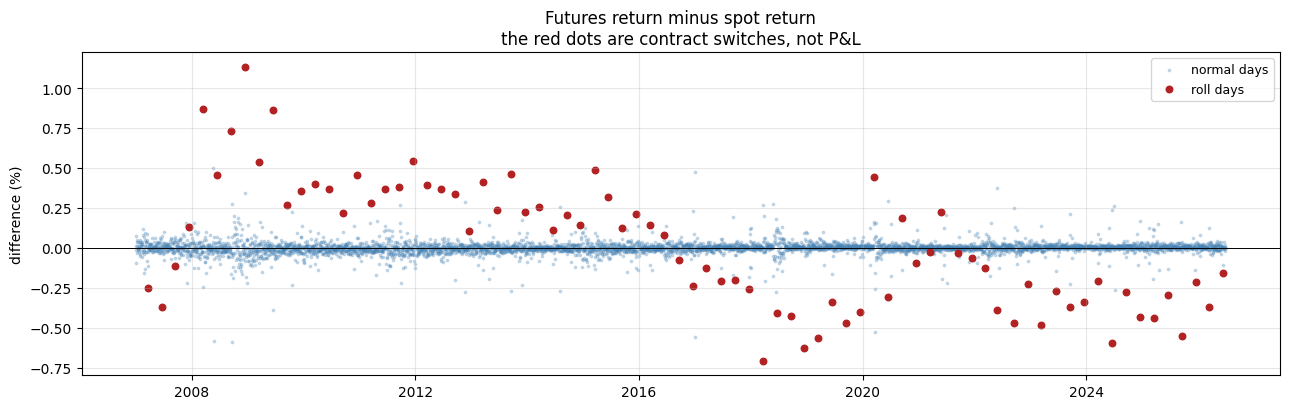

In [5]:
fig, ax = plt.subplots(figsize=(13, 4.2))
ax.scatter(off.index, off.values * 100, s=3, alpha=0.25, color="steelblue", label="normal days")
ax.scatter(on.index, on.values * 100, s=22, color="firebrick", label="roll days")
ax.axhline(0, color="k", lw=0.7)
ax.set_title("Futures return minus spot return\nthe red dots are contract switches, not P&L")
ax.set_ylabel("difference (%)"); ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

> **The rolls are obvious and they're big.** On roll days the futures return sits ~0.34% away from
> spot; on every other day it's ~0.02%. That's ~14x noisier, on four dates a year we can predict in
> advance.
>
> **Fix:** replace the roll-day return with the spot return for that day. We can't observe what the
> held contract actually did, and since the two instruments track each other at ~0.99 daily, this is
> a mild assumption. (§7 checks that dropping the day instead changes nothing.)

In [6]:
dx1_adj  = dx1_raw.copy(); dx1_adj.loc[ROLLS]  = dxy_ret.reindex(ROLLS); dx1_adj.name = "DX1_adj"
dx1_drop = dx1_raw.copy(); dx1_drop.loc[ROLLS] = np.nan;                    dx1_drop.name = "DX1_drop"

print("correlation with spot:")
print(f"  raw futures    {dx1_raw.corr(dxy_ret):.5f}")
print(f"  roll-adjusted  {dx1_adj.corr(dxy_ret):.5f}   (+{dx1_adj.corr(dxy_ret)-dx1_raw.corr(dxy_ret):.5f})")

correlation with spot:
  raw futures    0.99039
  roll-adjusted  0.99571   (+0.00532)


> Removing 78 days out of ~5,000 takes the correlation from 0.990 to 0.996. So the old notebook's
> "futures and spot are ~0.99 correlated" assumption was **correct** — it was just correct despite the
> contamination rather than because the series was clean.

## 4. Does the hedge ratio survive the switch to futures?

The old notebook sized the hedge on the spot beta and assumed it would carry over. That's now
testable. Same regressions as before, run against three versions of the dollar.

**If the futures beta lands somewhere else, every number in the old notebook was sized on the wrong
instrument.** If it lands on top, the old verdict stands and this comes down to costs.

In [7]:
def book_on(x, book, blabel, xlabel):
    r = fx.nw_regression(win(book), win(x).to_frame("X"), lags=5)
    return {"book": blabel, "vs": xlabel, "beta": r["beta_X"],
            "t_beta": r["t_X"], "r2": r["r2"], "n": r["n"]}

series = [("DXY spot", dxy_ret), ("DX1 raw", dx1_raw), ("DX1 roll-adj", dx1_adj)]
books  = [("G10_net", g10_net), ("EM_net", em_net), ("ALL_net", all_net)]
beta_tab = pd.DataFrame([book_on(x, b, bl, xl)
                         for bl, b in books for xl, x in series]).set_index(["book", "vs"])
print("book P&L regressed on each dollar series (Newey-West):")
print(beta_tab.round(4).to_string())

b_spot = beta_tab.loc[("ALL_net", "DXY spot"), "beta"]
b_fut  = beta_tab.loc[("ALL_net", "DX1 roll-adj"), "beta"]
print(f"\ncombined book: spot {b_spot:+.4f} -> futures {b_fut:+.4f}  ({(b_fut/b_spot-1)*100:+.1f}%)")

book P&L regressed on each dollar series (Newey-West):
                        beta  t_beta      r2     n
book    vs                                        
G10_net DXY spot     -0.0090 -0.2756  0.0000  4994
        DX1 raw      -0.0100 -0.3093  0.0000  4994
        DX1 roll-adj -0.0128 -0.3965  0.0001  4994
EM_net  DXY spot     -0.0941 -2.8709  0.0040  4994
        DX1 raw      -0.0947 -2.9298  0.0042  4994
        DX1 roll-adj -0.0940 -2.9008  0.0041  4994
ALL_net DXY spot      0.2991  8.7248  0.0392  4994
        DX1 raw       0.2888  8.4763  0.0378  4994
        DX1 roll-adj  0.2920  8.5716  0.0385  4994

combined book: spot +0.2991 -> futures +0.2920  (-2.4%)


> **The hedge ratio transfers.** The combined book's beta against the tradable contract is within a
> few percent of the spot beta, same sign, same significance, same R². The small shrinkage is what
> you'd expect from the index print and the futures settle being timed slightly differently.
>
> So the old notebook was sized on the right number, and nothing about the real contract rescues the
> exposure. It's still the euro-funding tilt, still positive, still explaining under 4% of the book.

## 5. The one thing futures add: roll yield

Futures price the **interest differential** between the dollar and the DXY basket. When US rates are
above the basket's, the future trades below spot and drifts up to meet it — so a **long** futures
position earns that differential and a **short** one pays it.

Spot has nothing like this. A short-DXY hedge therefore has a running cost or credit that the old
notebook literally could not see.

$$\text{roll yield} = \frac{S - F}{F} \times \frac{365}{\text{days to expiry}}$$

In [8]:
dte = pd.Series({d: (EXPIRIES[EXPIRIES >= d][0] - d).days for d in px.index}).replace(0, np.nan)
roll_yield = (((px["DXY"] - px["DX1"]) / px["DX1"]) * (365.0 / dte)
              ).replace([np.inf, -np.inf], np.nan).rename("roll_yield")
ry = roll_yield[roll_yield.abs() < 0.25]

print("annualised roll yield on a LONG futures position")
print(f"  full sample : {ry.mean()*100:+.2f}%/yr")
print(f"  2007-2016   : {ry.loc[:'2016'].mean()*100:+.2f}%/yr")
print(f"  2017-2026   : {ry.loc['2017':].mean()*100:+.2f}%/yr")
print(f"\nat the book's hedge ratio h={b_fut:.2f} (short futures), the cost today is "
      f"{-b_fut*ry.loc['2017':].mean()*100:+.2f}%/yr")

annualised roll yield on a LONG futures position
  full sample : -0.08%/yr
  2007-2016   : -1.37%/yr
  2017-2026   : +1.27%/yr

at the book's hedge ratio h=0.29 (short futures), the cost today is -0.37%/yr


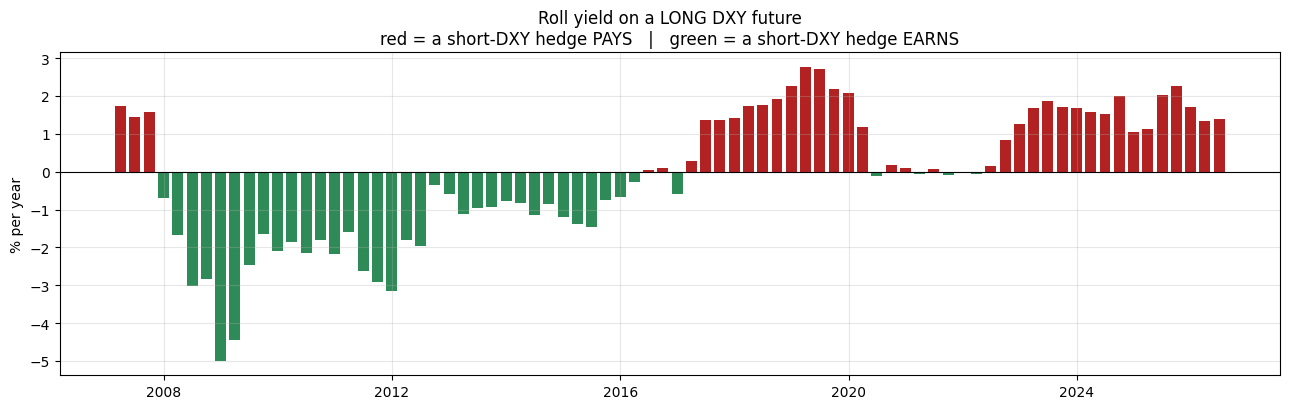

In [9]:
fig, ax = plt.subplots(figsize=(13, 4.2))
q = ry.resample("QE").mean() * 100
ax.bar(q.index, q.values, width=70,
       color=["firebrick" if v > 0 else "seagreen" for v in q.values])
ax.axhline(0, color="k", lw=0.8)
ax.set_title("Roll yield on a LONG DXY future\n"
             "red = a short-DXY hedge PAYS   |   green = a short-DXY hedge EARNS")
ax.set_ylabel("% per year")
plt.tight_layout(); plt.show()

> **This is the genuinely new fact, and it flips sign mid-sample.** Through 2008–2016, with the Fed at
> the floor and the basket yielding more, a short-DXY hedge was **paid** to exist. From 2017, with the
> Fed above the ECB/BoJ/SNB, the same hedge **pays out**.
>
> Two takeaways. The full-sample average flatters the hedge, because the half where it got paid is
> the half that's over. And more usefully: **a futures hedge quietly imports a rates bet.** Scaled by
> the book's ~0.3 beta it's small here, but any future overlay sized in futures should report this
> rather than let it hide inside the P&L.

## 6. The actual test

Hedge the combined book with the roll-adjusted contract and charge it properly:

- **rolling** the position 4x a year costs a full spread on the notional
- **resizing** it costs a half-spread on whatever changed
- **roll yield** is already inside the return series from §3 — adding it again would double-count

Three hedge ratios, from most optimistic to most honest:

| | how it's sized | realistic? |
|---|---|---|
| **static** | full-sample beta | no — it peeks at the answer |
| **dynamic** | yesterday's 1y rolling beta | yes |
| **expanding** | beta from all data up to yesterday | yes, strictest |

Everything is computed on **one common sample** so the comparisons are like-for-like.

In [10]:
# --- cost of the quoted spread, robust to bad prints ---
rel = ((px["DX1_ASK"] - px["DX1_BID"]) / px["DX1"])
usable = rel[(rel > 0) & (rel < 0.01)]
HALF_SPREAD = usable.median() / 2
print(f"quote quality : {(px['DX1_BID'] > px['DX1_ASK']).sum()} crossed, "
      f"{len(usable):,}/{len(px):,} usable")
print(f"half-spread   : {HALF_SPREAD*1e4:.2f}bp (median; mean is "
      f"{usable.mean()/2*1e4:.2f}bp, inflated by stale prints)")

# --- ONE common sample for every variant, so nothing is compared across different days ---
SAMPLE = win(all_net).dropna().index.intersection(dx1_adj.dropna().index)
book = all_net.reindex(SAMPLE)
fut  = dx1_adj.reindex(SAMPLE)
print(f"common sample : {len(SAMPLE):,} days, {SAMPLE.min().date()} -> {SAMPLE.max().date()}")

def hedged(h, charge=True):
    hs = h.reindex(SAMPLE).ffill().fillna(0.0) if isinstance(h, pd.Series) \
         else pd.Series(float(h), index=SAMPLE)
    r = book - hs * fut
    if charge:
        cost = pd.Series(0.0, index=SAMPLE)
        rr = SAMPLE.intersection(ROLLS)
        cost.loc[rr] += 2.0 * HALF_SPREAD * hs.reindex(rr).abs()   # quarterly roll
        cost += HALF_SPREAD * hs.diff().abs().fillna(0.0)          # resizing
        r = r - cost
    return r

def row(r, label):
    return fx.summary_stats(r.to_frame(label)).loc[
        label, ["ann_return", "ann_vol", "sharpe", "max_drawdown", "skew"]]

quote quality : 42 crossed, 4,395/5,087 usable
half-spread   : 2.26bp (median; mean is 5.11bp, inflated by stale prints)
common sample : 4,994 days, 2007-05-01 -> 2026-06-30


In [11]:
def rolling_beta(y, x, w=252, mp=126):
    d = pd.concat([y.rename("y"), x.rename("x")], axis=1, join="inner").dropna()
    return (d["y"].rolling(w, min_periods=mp).cov(d["x"]) /
            d["x"].rolling(w, min_periods=mp).var())

def expanding_beta(y, x, mp=252):
    d = pd.concat([y.rename("y"), x.rename("x")], axis=1, join="inner").dropna()
    return d["y"].expanding(mp).cov(d["x"]) / d["x"].expanding(mp).var()

h_static = b_fut
h_dyn    = rolling_beta(all_net, dx1_adj).shift(1)
h_exp    = expanding_beta(all_net, dx1_adj).shift(1)

rows = {"unhedged": row(book, "unhedged")}
for lab, h in [("static", h_static), ("dynamic", h_dyn), ("expanding", h_exp)]:
    rows[f"{lab} (no cost)"]  = row(hedged(h, charge=False), lab)
    rows[f"{lab} (net cost)"] = row(hedged(h, charge=True), lab)
hedge_stats = pd.DataFrame(rows).T
print("DXY futures hedge on the combined book:")
print(hedge_stats.round(4).to_string())

base = hedge_stats.loc["unhedged", "sharpe"]
print(f"\nSharpe change vs unhedged ({base:.4f}) on the same sample:")
for k in hedge_stats.index.drop("unhedged"):
    print(f"  {k:22s} {hedge_stats.loc[k,'sharpe']-base:+.4f}")

net_only = hedge_stats.loc[[i for i in hedge_stats.index if "net cost" in i]]
print(f"\nbest tradable hedge: {net_only['sharpe'].idxmax()} -> {net_only['sharpe'].max():.4f}")
print(f"  vs unhedged bar {BAR_UNHEDGED:.3f}: {net_only['sharpe'].max()-BAR_UNHEDGED:+.4f}")
print(f"  vs 25d-RR  bar {BAR_RR:.3f}: {net_only['sharpe'].max()-BAR_RR:+.4f}")
print(f"\nVERDICT: {'CLEARS' if net_only['sharpe'].max() > max(BAR_UNHEDGED, BAR_RR) else 'FAILS'} the bar.")

DXY futures hedge on the combined book:
                     ann_return   ann_vol    sharpe max_drawdown      skew
unhedged               0.052332  0.111991  0.467288    -0.293185 -0.647886
static (no cost)        0.04946  0.109815  0.450391    -0.284053 -0.690156
static (net cost)      0.048953  0.109814  0.445784     -0.28481 -0.690288
dynamic (no cost)      0.042054  0.107676  0.390563    -0.329765  -0.70833
dynamic (net cost)     0.040905  0.107697  0.379821    -0.340472 -0.709981
expanding (no cost)    0.049282  0.109888  0.448469    -0.286726 -0.660221
expanding (net cost)   0.048996  0.109887  0.445877    -0.287393 -0.660306

Sharpe change vs unhedged (0.4673) on the same sample:
  static (no cost)       -0.0169
  static (net cost)      -0.0215
  dynamic (no cost)      -0.0767
  dynamic (net cost)     -0.0875
  expanding (no cost)    -0.0188
  expanding (net cost)   -0.0214

best tradable hedge: expanding (net cost) -> 0.4459
  vs unhedged bar 0.466: -0.0201
  vs 25d-RR  bar 0.4

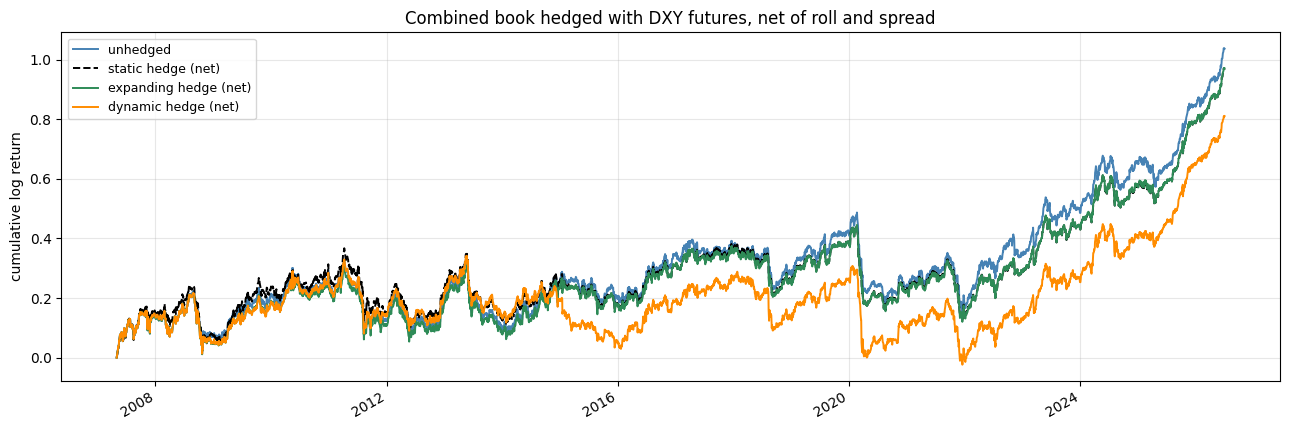

In [12]:
fig, ax = plt.subplots(figsize=(13, 4.4))
for lab, s, c, ls in [("unhedged", book, "steelblue", "-"),
                      ("static hedge (net)", hedged(h_static), "black", "--"),
                      ("expanding hedge (net)", hedged(h_exp), "seagreen", "-"),
                      ("dynamic hedge (net)", hedged(h_dyn), "darkorange", "-")]:
    s.cumsum().plot(ax=ax, label=lab, color=c, ls=ls, lw=1.4)
ax.set_title("Combined book hedged with DXY futures, net of roll and spread")
ax.set_ylabel("cumulative log return"); ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

> **Every version loses.** The static hedge — which cheats by using the whole sample — is the least
> bad and still costs Sharpe. The strict expanding-window hedge, the only one a desk could genuinely
> have run, is worse. The lagged-rolling hedge is worst of all, because it chases a beta that keeps
> changing sign.
>
> Skew gets *worse* in every variant too, so there isn't even a tail-risk consolation prize.
>
> Note what this is **not** about: at a hedge ratio near 0.3 and four rolls a year, the friction is a
> few basis points. **The hedge doesn't fail because futures are expensive.** It fails for the reason
> §6 of the old notebook found — a dollar-neutral carry sort has already cancelled the dollar out, so
> there's barely anything left to hedge, and what's left is the compensated funding leg.

## 7. Is it just badly sized? Sweeping every hedge ratio

The obvious objection: maybe the *estimate* is bad, not the instrument. So forget estimating — just
try every hedge size and see if **any** of them helps.

This is the cleanest possible test because no beta is involved. Compared against **h = 0 on the same
sample**, which is the only apples-to-apples benchmark.

h = 0 on this sample      : 0.4673
best h over the sweep     : -0.050  ->  0.4676
improvement over h = 0    : +0.0003
estimated h = +0.29        : 0.4449


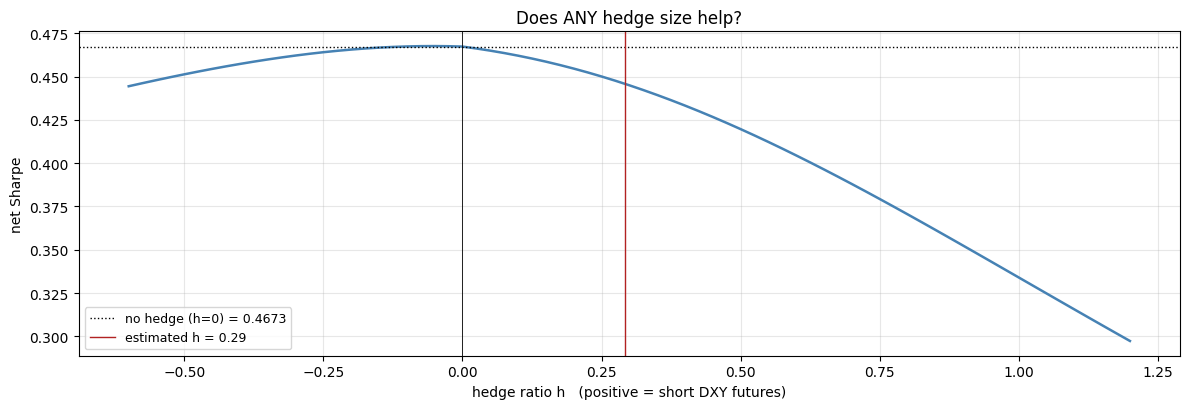

In [13]:
hs = np.linspace(-0.6, 1.2, 73)
sw = pd.Series([row(hedged(h), "h")["sharpe"] for h in hs], index=hs)
sw0 = sw.iloc[int(np.argmin(np.abs(hs)))]          # h = 0 on this same sample

print(f"h = 0 on this sample      : {sw0:.4f}")
print(f"best h over the sweep     : {sw.idxmax():+.3f}  ->  {sw.max():.4f}")
print(f"improvement over h = 0    : {sw.max()-sw0:+.4f}")
print(f"estimated h = {h_static:+.2f}        : {sw.reindex([hs[np.argmin(np.abs(hs-h_static))]]).iloc[0]:.4f}")

fig, ax = plt.subplots(figsize=(12, 4.2))
ax.plot(sw.index, sw.values, color="steelblue", lw=1.8)
ax.axhline(sw0, color="k", ls=":", lw=1.0, label=f"no hedge (h=0) = {sw0:.4f}")
ax.axvline(h_static, color="firebrick", lw=1.0, label=f"estimated h = {h_static:.2f}")
ax.axvline(0, color="k", lw=0.6)
ax.set_xlabel("hedge ratio h   (positive = short DXY futures)")
ax.set_ylabel("net Sharpe")
ax.set_title("Does ANY hedge size help?")
ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

> **The curve peaks essentially at zero.** Any gain over "no hedge at all" is in the third decimal —
> noise, not signal — and the peak sits at a hedge ratio nowhere near the estimated one. Meanwhile the
> beta-sized hedge sits visibly below the no-hedge line.
>
> So the problem isn't sizing. There is no size of DXY futures position that improves this book.

## 8. Does anything hinge on a judgement call?

Two choices could be argued with: how the rolls were adjusted, and how expensive we assumed trading
is. Both are swept rather than defended.

In [14]:
rob = {}
for lab, x in [("roll fix: spot substitute", dx1_adj),
               ("roll fix: drop the day", dx1_drop),
               ("no roll fix at all", dx1_raw)]:
    xs = x.reindex(SAMPLE)
    b  = fx.nw_regression(win(all_net), win(x).to_frame("X"), lags=5)["beta_X"]
    hs_ = pd.Series(b, index=SAMPLE)
    r = book - hs_ * xs.fillna(0.0)
    cost = pd.Series(0.0, index=SAMPLE)
    cost.loc[SAMPLE.intersection(ROLLS)] += 2 * HALF_SPREAD * abs(b)
    rob[lab] = {"beta": b, "sharpe": row((r - cost).dropna(), "h")["sharpe"]}

for mult, lab in [(1, "median spread"), (2, "2x spread"), (5, "5x spread"),
                  (usable.mean() / usable.median(), "mean spread (stale prints incl.)")]:
    g = HALF_SPREAD
    globals()["HALF_SPREAD"] = g * mult
    rob[f"cost: {lab}"] = {"beta": h_static, "sharpe": row(hedged(h_static), "h")["sharpe"]}
    globals()["HALF_SPREAD"] = g

rob = pd.DataFrame(rob).T
rob["vs_no_hedge"] = rob["sharpe"] - sw0
print("robustness (combined book, net of cost):")
print(rob.round(4).to_string())
print(f"\nanything beating no-hedge ({sw0:.4f})? "
      f"{'YES' if (rob['sharpe'] > sw0).any() else 'NO'}")

robustness (combined book, net of cost):
                                          beta  sharpe  vs_no_hedge
roll fix: spot substitute               0.2920  0.4458      -0.0215
roll fix: drop the day                  0.2955  0.4395      -0.0278
no roll fix at all                      0.2888  0.4444      -0.0229
cost: median spread                     0.2920  0.4458      -0.0215
cost: 2x spread                         0.2920  0.4412      -0.0261
cost: 5x spread                         0.2920  0.4273      -0.0400
cost: mean spread (stale prints incl.)  0.2920  0.4400      -0.0273

anything beating no-hedge (0.4673)? NO


> Nothing moves. The roll-adjustment choice changes the beta in the third decimal. Multiplying the
> cost assumption by five — past the mean spread including stale quotes — moves Sharpe by a few
> thousandths, because the friction was never the binding constraint.

## 9. Save

In [15]:
beta_tab.to_csv(OUT / "dxyfut_book_betas.csv")
hedge_stats.to_csv(OUT / "dxyfut_hedge_stats.csv")
rob.to_csv(OUT / "dxyfut_robustness.csv")
sw.rename("sharpe").to_frame().to_csv(OUT / "dxyfut_hedge_ratio_sweep.csv")
pd.DataFrame({"basis": basis, "roll_yield": roll_yield,
              "is_roll": px.index.isin(ROLLS)}).to_csv(OUT / "dxyfut_basis_rollyield.csv")
pd.DataFrame({"DXY": dxy_ret, "DX1_raw": dx1_raw,
              "DX1_adj": dx1_adj}).to_csv(OUT / "dxyfut_return_series.csv")

try:
    wide = pd.DataFrame({f"{t.split()[0]}_{f}": s for (n, t, f), s in dollar.items()})
    Path("../data/raw").mkdir(parents=True, exist_ok=True)
    wide.to_parquet("../data/raw/hedge_dollar_wide.parquet")
    print("wrote ../data/raw/hedge_dollar_wide.parquet", wide.shape)
except Exception as e:
    print("parquet write skipped:", e)

print("written:", sorted(p.name for p in OUT.glob("dxyfut_*.csv")))

wrote ../data/raw/hedge_dollar_wide.parquet (5087, 5)
written: ['dxyfut_basis_rollyield.csv', 'dxyfut_book_betas.csv', 'dxyfut_hedge_ratio_sweep.csv', 'dxyfut_hedge_stats.csv', 'dxyfut_regime_table.csv', 'dxyfut_return_series.csv', 'dxyfut_robustness.csv', 'dxyfut_roll_dates.csv']


## Conclusion

**The futures don't change the answer. A DXY overlay is a confirmed null.**

What the tradable contract established:

1. **The old notebook was sized correctly.** The book's beta against the real contract is within a
   few percent of the spot beta — same sign, same significance, same R². Spot was a fair proxy.
2. **The rolls were real and had to be removed.** 78 quarterly contract switches, each injecting a
   fake return ~14x the size of a normal day's tracking error. Skipping this step would have meant
   measuring the contract calendar instead of the dollar.
3. **Every hedge loses, net of real costs.** Static, dynamic and strict out-of-sample all land below
   the unhedged book, and none approaches either bar.
4. **It isn't a cost problem.** Five times the spread assumption barely moves it. And the hedge-ratio
   sweep — which uses no estimate at all — peaks at essentially zero. There is no size that works.
5. **New from futures: a roll yield that flips sign.** A short-DXY hedge was paid ~1-3%/yr through
   2008-2016 and pays out ~1.5-2.5%/yr since 2017. Small at this book's beta, but it means **a
   futures hedge quietly carries a rates bet**, which spot analysis cannot reveal.

**Why it fails** is unchanged from §6 of `dxy_hedging.ipynb`: a carry sort is long some currencies and
short others against the dollar, so the dollar largely cancels between the legs before any hedge is
applied. What survives is the compensated euro-funding tilt — a position the carry signal deliberately
wanted. Hedging it sells premium at roughly the rate it sheds risk.

Two independent instruments, same mechanism, same null. **This line is closed.**

**Where to go instead.** DXY of either form sees the funding leg and not the EM crash channel. The
workbook's remaining tabs point at the actual risk:

- `Credit_Spreads` / `Credit_TR_ETF` — EMB, CDX HY, six sovereign 5Y CDS
- `FXVol_Indices` — JPMVXYEM
- `FX_Options_3M` — ATM vol, 25d RR, 25d BF across 21 pairs

Two lessons to carry over. **Use downside-conditioned betas, not full-sample linear ones** — the
full-sample linear beta is exactly what washed out here. And **report skew and drawdown alongside
Sharpe**, since a treasury desk hedges the left tail rather than the ratio.

**One data warning for the next ingest:** the `FX_Fwd_*` tabs hold forward **points**, not outright
forwards, despite the handoff describing them as outrights. JPY and HUF need a /100 divisor,
everything else /10000. The carry book is unaffected (it comes from the repo parquets), but anything
built directly from those tabs will be silently wrong.